# 014 · AR-MA · Teoría y Laboratorio

**Estadística, Detección de Anomalías e Imputación de Series Temporales**
Posgrado en Ingeniería · Área Energía · IER-UNAM

Sesión de **90 minutos**: 45 teoría + 45 laboratorio.
Plan completo: `PLAN-AR-MA.md`.


---
### Cómo usar esta libreta — guía para el instructor

Las celdas tipo **`> Notas para el instructor`** (citas con `>`) son señales pedagógicas:

- **Notas para el instructor** — lo que conviene hacer/decir en ese momento (pizarrón, demostración manual, ritmo).
- **Para discutir con la clase** — preguntas abiertas para detener la ejecución y abrir conversación.
- **Errores comunes** — confusiones recurrentes que conviene anticipar.
- **Pausa pedagógica** — momentos donde no hay que correr la siguiente celda hasta que los alumnos opinen.

Si vas justo de tiempo, salta las pausas pedagógicas pero **no** los puntos de discusión: son los que fijan el aprendizaje.

---

## Apertura · 5 min

> *"Mañana vas a operar un parque eólico en La Ventosa. Tienes 3 meses de viento
> horario. ¿Puedes pronosticar la siguiente hora con esos datos solos?"*

Una serie temporal es la realización de un **proceso estocástico** ordenado en el tiempo.
Modelarla = explicar el valor actual a partir de:

- su **pasado** (componente autorregresivo, AR), y/o
- los **choques aleatorios pasados** (componente de media móvil, MA).

Lugar en el curso: tras EDA y descomposición; antes de SARIMA, espacio-estados y ML.

> **Para discutir con la clase (3 min).**
> - ¿Qué métodos conocen ya para pronosticar series? (probable: regresión, promedios móviles, "ojo experto").
> - Si no tuvieran computadora, ¿qué predecirían para mañana a las 14:00? Anclar la intuición *antes* de mostrar máquinas.
> - ¿Por qué el viento podría ser más predecible "a la siguiente hora" que "a los siete días"?

> **Notas para el instructor.** No abrir la teoría hasta que alguien diga al menos una vez "depende de lo que pasó antes". Esa frase es la entrada natural a AR(p).

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
np.random.seed(42)

## Helpers — los dos pasos del ciclo Box-Jenkins

Los reusaremos en cada iteración:
- `mirar()`: identificación (ADF + ACF + PACF).
- `diagnostico()`: validación (residuales + ACF residual + Ljung-Box).

In [4]:
def mirar(serie, nombre, lags=30):
    """Identificación: ADF + ACF + PACF."""
    serie = pd.Series(serie).dropna()

    stat, p, *_ = adfuller(serie, autolag="AIC")
    veredicto = "estacionaria" if p < 0.05 else "NO estacionaria"
    print(f"ADF · {nombre}:  estadístico = {stat:.3f},  p = {p:.4f}  →  {veredicto}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))
    plot_acf(serie,  lags=lags, ax=axes[0]); axes[0].set_title(f"ACF — {nombre}")
    plot_pacf(serie, lags=lags, ax=axes[1], method="ywm")
    axes[1].set_title(f"PACF — {nombre}")
    plt.tight_layout(); plt.show()


def diagnostico(modelo, nombre, lags=20):
    """Validación: residuales + ACF residual + Ljung-Box."""
    p, d, q = modelo.model.order
    resid = modelo.resid.iloc[max(p, q):]

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))
    axes[0].plot(resid.values, lw=0.6); axes[0].axhline(0, color="k", lw=0.5)
    axes[0].set_title(f"Residuales — {nombre}")
    plot_acf(resid, lags=lags, ax=axes[1])
    axes[1].set_title("ACF de residuales")
    plt.tight_layout(); plt.show()

    lb = acorr_ljungbox(resid, lags=[10, 20], return_df=True)
    print(f"Ljung-Box · {nombre}")
    print(lb.round(4))
    return lb

# Bloque 1 · Teoría (45 min)

## T1 · Estacionariedad · 10 min

**Definición débil (covarianza-estacionaria).** Un proceso $\{y_t\}$ es estacionario
en sentido débil si:

1. $E[y_t] = \mu$ constante en $t$,
2. $\mathrm{Var}(y_t) = \sigma^2$ constante en $t$,
3. $\mathrm{Cov}(y_t, y_{t+k}) = \gamma(k)$ depende solo del rezago $k$, no de $t$.

**Por qué importa.** ARMA solo está bien definido —y los estimadores son
consistentes— sobre un proceso estacionario. Si la serie tiene tendencia o
estacionalidad, los parámetros que estimes no significan nada estable.

**Prueba operativa: ADF (Augmented Dickey-Fuller).**
- $H_0$: existe raíz unitaria → **no** estacionaria.
- $H_1$: estacionaria.
- Regla: $p < 0.05$ → rechazo $H_0$ → trabajable con ARMA.

Si **no** es estacionaria: diferenciar (lleva a ARIMA), restar tendencia,
o restar climatología (lo que haremos en el laboratorio).

> **Notas para el instructor.** Antes de correr el demo, dibujar en pizarrón dos series
> a mano: una que oscila alrededor de un nivel, otra que vaga sin volver. Pedir a los alumnos
> que digan cuál parece "predecible". El concepto de estacionariedad cala mucho mejor
> después de ese ejercicio manual de 90 segundos.

> **Errores comunes que hay que desactivar pronto.**
> 1. Confundir estacionariedad con "no tiene tendencia". La estacionariedad es más estricta:
>    también exige varianza y autocovarianza estables.
> 2. Pensar que el ADF detecta estacionalidad. **No lo hace.** Detecta raíces unitarias.
>    Una serie con ciclo diario perfecto puede pasar el ADF sin problema (lo veremos en el lab).

### Demo · estacionario vs no estacionario

Comparamos dos series del mismo largo: un AR(1) estable vs una caminata aleatoria
(raíz unitaria). Visualmente la diferencia salta; ADF lo confirma.

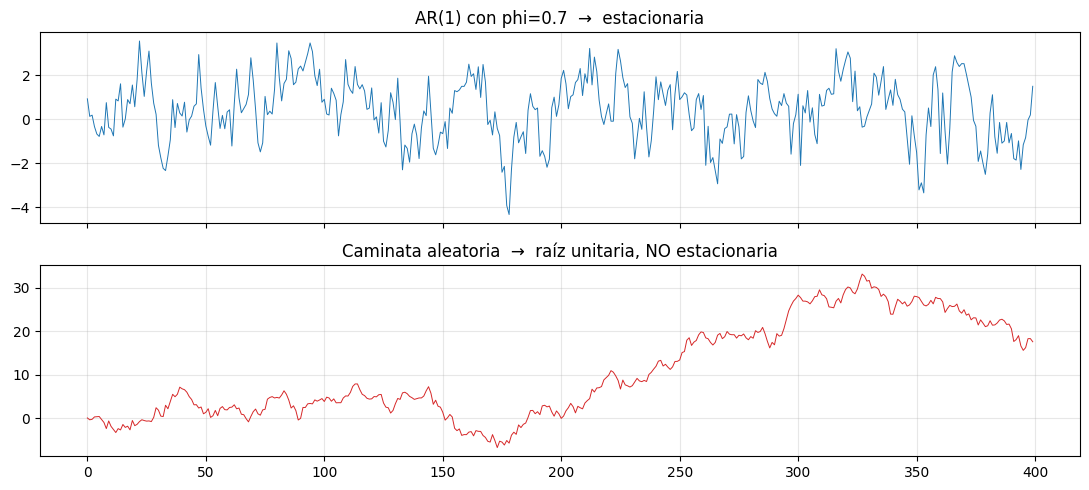

ADF · AR(1) estable       p = 0.0000  →  estacionaria
ADF · caminata            p = 0.7290  →  NO estacionaria


In [5]:
N = 400
estacionaria = pd.Series(ArmaProcess(ar=[1, -0.7], ma=[1]).generate_sample(N))
caminata     = pd.Series(np.random.randn(N).cumsum())

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
estacionaria.plot(ax=axes[0], lw=0.7, color="C0")
axes[0].set_title("AR(1) con phi=0.7  →  estacionaria")
caminata.plot(ax=axes[1], lw=0.7, color="C3")
axes[1].set_title("Caminata aleatoria  →  raíz unitaria, NO estacionaria")
plt.tight_layout(); plt.show()

for nombre, s in [("AR(1) estable", estacionaria), ("caminata", caminata)]:
    stat, p, *_ = adfuller(s, autolag="AIC")
    print(f"ADF · {nombre:18s}  p = {p:.4f}  →  {'estacionaria' if p < 0.05 else 'NO estacionaria'}")

El AR(1) oscila alrededor de un nivel; la caminata vaga sin volver. **ADF lo certifica.**
Esa es la primera puerta antes de tocar `ARIMA(...)`.

> **Para discutir con la clase.**
> - Si forzáramos un AR(1) sobre la caminata aleatoria, ¿qué $\phi$ esperarían? (Respuesta:
>   muy cercano a 1, pero el modelo estaría **mal especificado** y los IC del pronóstico
>   serían engañosamente estrechos).
> - ¿Conocen series reales que se parezcan a la caminata? (Pistas: precios bursátiles, niveles
>   piezométricos sin recarga, posición de un objeto sometido solo a ruido).
> - ¿Por qué el ADF se llama *aumentado*? (Versión simple Dickey-Fuller agrega lags de la
>   diferencia para absorber autocorrelación de orden mayor a 1).

## T2 · Modelo AR(p) · 10 min

**Ecuación.**
$$
y_t = c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + \cdots + \phi_p y_{t-p} + \varepsilon_t,
\qquad \varepsilon_t \sim \mathrm{WN}(0, \sigma^2)
$$

**Intuición física: *inercia*.** El sistema "recuerda" su pasado reciente.
Ejemplo: el nivel del lago Hurón hoy depende del de ayer porque el agua tarda
en entrar/salir. Cualquier desviación se relaja exponencialmente al equilibrio.

**Condición de estacionariedad.** Las raíces de
$1 - \phi_1 z - \cdots - \phi_p z^p = 0$ deben caer **fuera** del círculo unitario.
Para AR(1): $|\phi| < 1$.

**Firma diagnóstica:**

| | ACF | PACF |
|---|---|---|
| AR(p) | decae geométricamente | **corta** después del lag $p$ |

La PACF "corta" porque mide correlación parcial: una vez que controlas los lags
$1, \dots, p$, el resto del pasado ya no aporta nada nuevo.

> **Para discutir con la clase.**
> - Den **tres ejemplos físicos** de inercia que podrían modelarse como AR. Pistas: térmicos
>   (una habitación tarda en cambiar de temperatura), hidráulicos (lago, embalse), económicos
>   (inventarios). Forzar a que los ejemplos vengan de su área.
> - ¿Qué pasa con $\phi = 1$? (Caminata aleatoria — caso límite, justo lo que vimos antes).
> - ¿Qué pasa con $\phi$ negativo? (La serie alterna de signo cada paso — describe sistemas
>   con sobrerreacción/oscilación).
> - ¿Por qué $\phi > 1$ es problema? (Explosivo: cada desviación crece sin acotar).

### Demo · AR(1) sintético

Generamos $y_t = 0.8 \, y_{t-1} + \varepsilon_t$ con $N=500$ y miramos su firma.

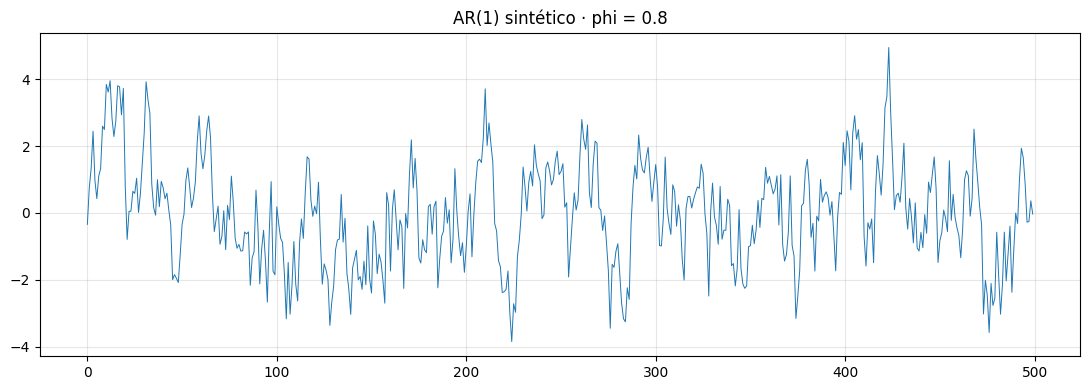

ADF · AR(1):  estadístico = -8.021,  p = 0.0000  →  estacionaria


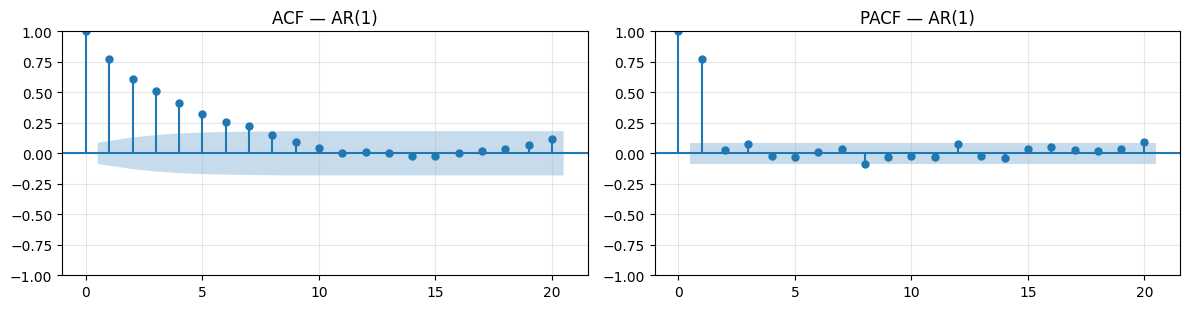

In [21]:
phi_true = 0.8
y_ar1 = pd.Series(ArmaProcess(ar=[1, -phi_true], ma=[1]).generate_sample(500))

y_ar1.plot(lw=0.7, color="C0", title=f"AR(1) sintético · phi = {phi_true}")
plt.tight_layout(); plt.show()

mirar(y_ar1, "AR(1)", lags=20)

**Lo que tenemos que ver.** ACF que decae suave; PACF con un único pico claro en lag 1
y todo lo demás dentro de banda. Esa es la firma textbook del AR(1). Verifiquemos
que el ajuste recupera el coeficiente:

In [5]:
ar1_fit = ARIMA(y_ar1, order=(1, 0, 0)).fit()

print(f"AR(1):  phi verdadero = {phi_true},  estimado = {ar1_fit.params['ar.L1']:.3f}")

AR(1):  phi verdadero = 0.8,  estimado = 0.803


Con $N=500$ recuperamos $\phi$ a una o dos centésimas. **El procedimiento funciona.**

> **Notas para el instructor.** Si alguien pregunta por la convención `ar=[1, -phi]` de
> statsmodels: viene de escribir el AR(1) como $(1 - \phi L) y_t = \varepsilon_t$, donde
> $L$ es el operador de rezago. statsmodels recibe los coeficientes del polinomio
> $1 - \phi L$, por eso `[1, -phi]`. Es la pregunta-trampa típica del primer encuentro.

## T3 · Modelo MA(q) · 10 min

**Ecuación.**
$$
y_t = \mu + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \theta_2 \varepsilon_{t-2}
      + \cdots + \theta_q \varepsilon_{t-q}
$$

**Intuición física: *eco de choques*.** Hubo una sorpresa hace 1, 2, ..., $q$ pasos
y todavía se siente. Pasados $q$ pasos, el efecto se extingue por completo.

**Estacionariedad.** Un MA finito siempre es estacionario (es combinación lineal
acotada de ruido blanco). La condición análoga es la **invertibilidad**: raíces de
$1 + \theta_1 z + \cdots + \theta_q z^q = 0$ fuera del círculo unitario, para que
el MA tenga una representación AR(∞) equivalente.

**Firma diagnóstica (espejo del AR):**

| | ACF | PACF |
|---|---|---|
| MA(q) | **corta** después del lag $q$ | decae geométricamente |

> **Errores comunes.**
> 1. Confundir el MA(q) con la **media móvil descriptiva** (rolling mean) que se usa
>    para suavizar series. **No son lo mismo.** El MA(q) modela ecos de innovaciones
>    aleatorias; el rolling mean es un filtro determinista.
> 2. Olvidar la invertibilidad. Si $|\theta| \geq 1$ en MA(1), el modelo "ajusta" pero
>    los residuales no son únicos y la representación no es interpretable.

> **Para discutir con la clase.**
> - Den **dos ejemplos de "eco de choques"** en su área. Pistas: shocks de demanda en
>   inventarios, anuncios de política monetaria que se digieren en 2-3 trimestres,
>   error de medición de un sensor que arrastra un offset durante varias muestras.

### Demo · MA(1) sintético

Generamos $y_t = \varepsilon_t + 0.8 \, \varepsilon_{t-1}$ y comparamos con el AR(1) anterior.

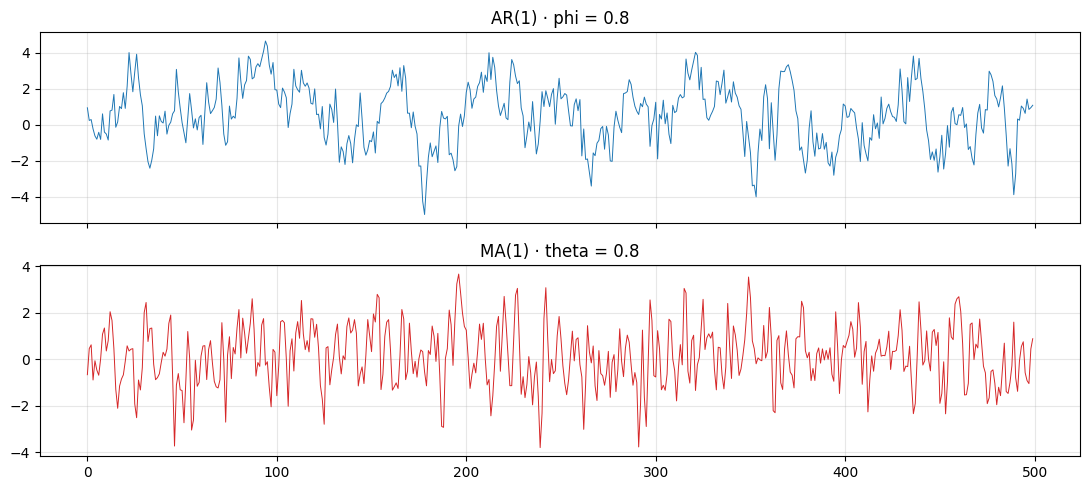

In [6]:
theta_true = 0.8
y_ma1 = pd.Series(ArmaProcess(ar=[1], ma=[1, theta_true]).generate_sample(500))

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
y_ar1.plot(ax=axes[0], lw=0.7, color="C0")
axes[0].set_title(f"AR(1) · phi = {phi_true}")
y_ma1.plot(ax=axes[1], lw=0.7, color="C3")
axes[1].set_title(f"MA(1) · theta = {theta_true}")
plt.tight_layout(); plt.show()

**Mira las dos series unos segundos.** A ojo son casi idénticas: la misma "textura"
de rachas. La diferencia entre AR y MA **no es visual** — es estructural, y se ve
en ACF/PACF. Por eso necesitamos esos dos diagnósticos.

> **Pausa pedagógica (60 s).** Antes de correr la siguiente celda, preguntar al grupo:
> "¿Cuál creen que es AR y cuál MA mirando solo las series?" Recoger las respuestas
> a mano alzada. La división estará cerca de 50/50 — esa **es la lección**: el ojo
> no basta, los diagnósticos sí.

ADF · MA(1):  estadístico = -6.051,  p = 0.0000  →  estacionaria


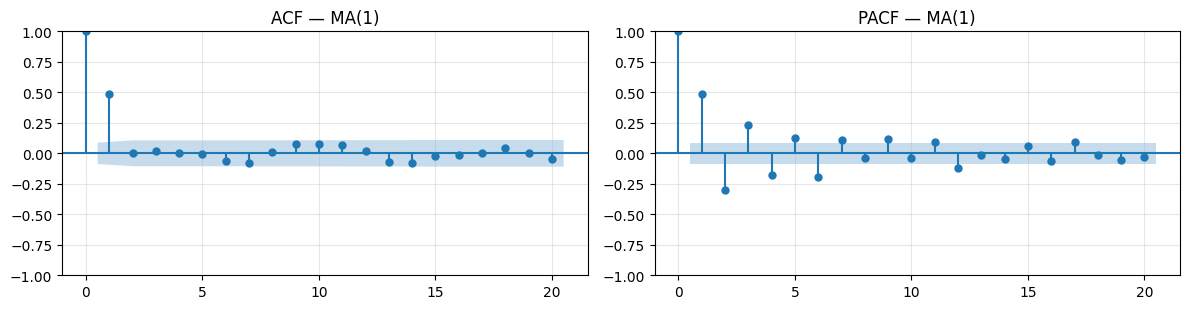

In [7]:
mirar(y_ma1, "MA(1)", lags=20)

In [8]:
ma1_fit = ARIMA(y_ma1, order=(0, 0, 1)).fit()
print(f"MA(1):  theta verdadero = {theta_true},  estimado = {ma1_fit.params['ma.L1']:.3f}")

MA(1):  theta verdadero = 0.8,  estimado = 0.884


**La firma es espejo de la del AR(1):** ACF que **corta** después de lag 1,
PACF que decae. Si memorizas esta tabla, ya tienes el 80% de la identificación:

| | ACF | PACF |
|---|---|---|
| AR(p) | decae | corta en lag $p$ |
| MA(q) | corta en lag $q$ | decae |
| ARMA(p,q) | decae | decae |

> **Para discutir con la clase.**
> - Si una serie real tiene ACF que decae **y** PACF que decae, ¿qué orden propondrían?
>   (Respuesta: ARMA(p,q) con ambos $> 0$. La fila más difícil de la tabla, porque ya
>   no es trivial elegir $p$ y $q$ — ahí es donde Box-Jenkins se vuelve iterativo).
> - ¿Por qué la PACF de un MA decae en lugar de cortar? (Pista: un MA(q) es equivalente
>   a un AR(∞), y un AR de orden infinito tiene PACF que decae).

## T4 · ARMA(p,q) y metodología Box-Jenkins · 10 min

**Ecuación combinada.**
$$
y_t = c + \sum_{i=1}^{p} \phi_i y_{t-i}
        + \varepsilon_t + \sum_{j=1}^{q} \theta_j \varepsilon_{t-j}
$$

**Por qué combinar.** Los procesos reales rara vez son AR puro o MA puro.
ARMA da **parsimonia**: a veces ARMA(1,1) ajusta lo mismo que AR(5) o MA(7),
con muchos menos parámetros.

**Metodología Box-Jenkins (1970)** — el corazón operativo de toda la sesión:

1. **Identificar.** ADF → ACF → PACF → hipótesis de orden $(p, q)$.
2. **Estimar.** Ajustar el modelo (máxima verosimilitud).
3. **Diagnosticar.** ¿Los residuales son ruido blanco?
   - ACF residual dentro de bandas.
   - **Ljung-Box**: $H_0$ "los residuales no están autocorrelacionados".
     $p > 0.05$ → no se rechaza → modelo adecuado.
4. **Si falla:** subir $p$ o $q$ y volver a 2.
5. **Si nunca pasa:** el problema **no es de orden** — falta estacionalidad,
   exógenas, o no linealidad.

**Criterios de selección.**
- **AIC, BIC**: comparar modelos. Menor es mejor (pero no es el único criterio).
- **Significancia de coeficientes**: si el último $\phi$ o $\theta$ no es
  significativo, sobreajustaste.
- **Parsimonia**: a igualdad de diagnóstico, gana el modelo con menos parámetros.

Con esto cerramos la teoría. Ahora vamos a vivir el ciclo completo sobre datos reales.

> **Notas para el instructor.** Dibujar el ciclo Box-Jenkins en el pizarrón como un
> diagrama de flujo: caja → caja → rombo de decisión → flecha de retorno. Es la
> única figura **que el alumno debe poder dibujar de memoria** al final de la sesión.
> Si no la puede dibujar, no entendió el método.

> **Para discutir con la clase.**
> - **AIC vs BIC**: cuando dan resultados distintos, ¿cuál usar? (BIC penaliza más fuerte
>   los parámetros — es asintóticamente consistente para selección de modelo verdadero;
>   AIC es mejor para predicción. Para Box-Jenkins en producción, BIC tiende a elegir
>   modelos más parsimoniosos).
> - ¿Qué pasaría si Ljung-Box rechaza pero AIC es bajo? (Modelo mal especificado pero
>   que ajustó bien la varianza. El AIC puede mentir si los residuales no son blancos:
>   por eso el orden es **primero diagnóstico, luego AIC**, no al revés).
> - ¿Hay un "ARMA óptimo"? (No. Hay un ARMA *adecuado* — uno cuyos residuales son
>   indistinguibles de ruido blanco. Box-Jenkins busca *adecuación*, no optimalidad).

# Bloque 2 · Laboratorio (45 min)

## P1 · Los datos · La Ventosa, Oaxaca · 5 min

- **Sitio:** 16.55°N, 94.78°W. Corredor eólico del Istmo de Tehuantepec, uno de los
  mayores recursos eólicos del continente. Vientos térmicos por contraste de presión
  entre el Golfo de México y el Pacífico, canalizados por el istmo.
- **Periodo:** jun–ago 2023, resolución horaria.
- **Variable:** velocidad del viento a 10 m.
- **Fuente:** ERA5 (reanálisis ECMWF) vía Open-Meteo.

**Por qué este dataset para enseñar ARMA:**
- ~2200 obs → potencia estadística suficiente.
- Ciclo diario explícito → enseña por qué hay que desestacionalizar antes.
- Persistencia no trivial → forzará iterar Box-Jenkins (no se cierra al primer intento).
- Relevante para el alumno (energía eólica).

In [25]:
viento

time
2023-06-01 00:00:00    0.750000
2023-06-01 01:00:00    0.944444
2023-06-01 02:00:00    0.916667
2023-06-01 03:00:00    0.638889
2023-06-01 04:00:00    1.333333
                         ...   
2023-08-31 19:00:00    2.277778
2023-08-31 20:00:00    0.916667
2023-08-31 21:00:00    0.611111
2023-08-31 22:00:00    0.777778
2023-08-31 23:00:00    1.138889
Name: ws, Length: 2208, dtype: float64

2208 obs horarias · 2023-06-01 00:00:00 a 2023-08-31 23:00:00
media = 4.14 m/s
desv  = 2.37 m/s
máx   = 9.36 m/s


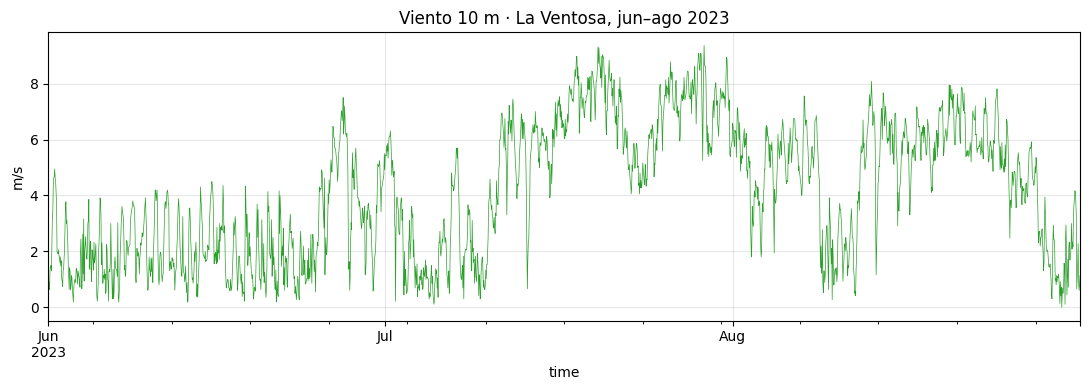

In [26]:
viento = pd.read_csv("../data/viento_la_ventosa_2023.csv",
                     skiprows=3, parse_dates=["time"],
                     index_col="time")
viento.columns = ["ws_kmh"]
viento["ws"] = viento["ws_kmh"] / 3.6  # km/h → m/s
viento = viento["ws"]

print(f"{len(viento)} obs horarias · {viento.index.min()} a {viento.index.max()}")
print(f"media = {viento.mean():.2f} m/s")
print(f"desv  = {viento.std():.2f} m/s")
print(f"máx   = {viento.max():.2f} m/s")

viento.plot(lw=0.5,color="C2", title="Viento 10 m · La Ventosa, jun–ago 2023")
plt.ylabel("m/s"); plt.tight_layout(); plt.show()

**Lectura a ojo.** Hay rachas multi-día (escala sinóptica) y un latido de alta
frecuencia que sugiere ciclo diario. Antes de tocar ARMA hay que verificar dos cosas:
(1) estacionariedad y (2) ausencia de estacionalidad determinista que se vaya a colar
a los residuales.

> **Para discutir con la clase.**
> - ¿Qué **otras variables físicas** querrían medir para mejorar el pronóstico?
>   (Presión, temperatura, gradiente térmico Golfo-Pacífico, índices climáticos como ENSO).
>   Anticipa el puente a SARIMAX/exógenas.
> - ¿Por qué viento a 10 m y no a altura de buje (~80 m)? (10 m es lo que da ERA5
>   con calidad estándar; para producción real se extrapola con perfil logarítmico
>   o se usan productos a 100 m. Con esta serie aprendemos *método*, no *operación*).
> - ¿Qué tan representativo es jun–ago de todo el año? (Mala. Es temporada de máximos
>   en La Ventosa — invierno tiene un régimen distinto. Lo veremos como ejercicio).

## P2 · ¿Podemos usar AR-MA aquí? · 10 min

In [27]:
viento

time
2023-06-01 00:00:00    0.750000
2023-06-01 01:00:00    0.944444
2023-06-01 02:00:00    0.916667
2023-06-01 03:00:00    0.638889
2023-06-01 04:00:00    1.333333
                         ...   
2023-08-31 19:00:00    2.277778
2023-08-31 20:00:00    0.916667
2023-08-31 21:00:00    0.611111
2023-08-31 22:00:00    0.777778
2023-08-31 23:00:00    1.138889
Name: ws, Length: 2208, dtype: float64

In [10]:
stat, p, *_ = adfuller(viento, autolag="AIC")
print(f"ADF sobre serie cruda:  p = {p:.4f}  →  "
      f"{'estacionaria' if p < 0.05 else 'NO estacionaria'}")

ADF sobre serie cruda:  p = 0.0668  →  NO estacionaria


El ADF rechaza raíz unitaria. Pero ADF **no detecta estacionalidad determinista** —
solo raíces unitarias. Verifiquemos el ciclo diario explícitamente.

> **Error común que aquí se vuelve operativo.** Un alumno apurado se quedaría con
> "ADF dice estacionaria, ergo puedo ajustar ARMA". **Es exactamente el error que
> queremos prevenir.** ADF certifica una propiedad necesaria pero **no suficiente**:
> la serie podría tener ciclo diario perfecto y aún pasar el ADF. La prueba final no
> es ADF sobre los datos — es Ljung-Box sobre los residuales.

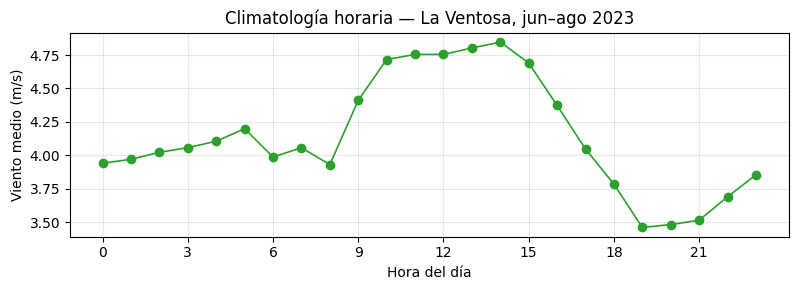

Rango climatológico: 3.46 a 4.85 m/s
Amplitud diaria:     1.39 m/s


In [29]:
clima_h = viento.groupby(viento.index.hour).mean()

fig, ax = plt.subplots(figsize=(8, 3))
clima_h.plot(ax=ax, marker="o", lw=1.2, color="C2")
ax.set_xlabel("Hora del día"); ax.set_ylabel("Viento medio (m/s)")
ax.set_title("Climatología horaria — La Ventosa, jun–ago 2023")
ax.set_xticks(range(0, 24, 3))
plt.tight_layout(); plt.show()

print(f"Rango climatológico: {clima_h.min():.2f} a {clima_h.max():.2f} m/s")
print(f"Amplitud diaria:     {clima_h.max() - clima_h.min():.2f} m/s")

Hay un ciclo diario marcado — el contraste térmico levanta el viento por la tarde.
Esa estructura es **determinista**: no la modelamos con ARMA, la **restamos** y
trabajamos sobre la anomalía. Lo que quede es lo que ARMA puede aspirar a explicar.

> **Para discutir con la clase (decisión de diseño).**
> - **Opción A:** restar climatología y modelar la anomalía con ARMA (lo que haremos).
> - **Opción B:** dejar la serie cruda y modelar todo con SARIMA $(p,d,q)(P,D,Q)_{24}$.
>
> ¿Trade-offs?
> - A es más interpretable (la climatología tiene significado físico explícito) y
>   permite separar "patrón conocido" de "dinámica residual".
> - B es más automático y maneja mejor cambios de fase del ciclo a lo largo del año.
> - En producción operativa de viento, lo más frecuente es **A**: pronostican la
>   anomalía y suman la climatología (a veces con una climatología más fina que
>   "media por hora", como una climatología por mes y hora).

In [30]:
clima_h

time
0     3.940519
1     3.970411
2     4.022343
3     4.057669
4     4.105374
5     4.198973
6     3.987017
7     4.057065
8     3.930556
9     4.411534
10    4.716486
11    4.754529
12    4.754529
13    4.802536
14    4.846618
15    4.690519
16    4.372886
17    4.047101
18    3.784722
19    3.460749
20    3.482488
21    3.514795
22    3.689614
23    3.854469
Name: ws, dtype: float64

In [31]:
viento.index.hour.map(clima_h)

Index([3.9405193236714977, 3.9704106280193234,  4.022342995169082,
        4.057669082125604,  4.105374396135266,  4.198973429951691,
       3.9870169082125604,  4.057065217391305, 3.9305555555555554,
        4.411533816425121,
       ...
        4.846618357487922,  4.690519323671498, 4.3728864734299515,
        4.047101449275362, 3.7847222222222223,  3.460748792270531,
       3.4824879227053143,  3.514794685990338, 3.6896135265700485,
        3.854468599033816],
      dtype='float64', name='time', length=2208)

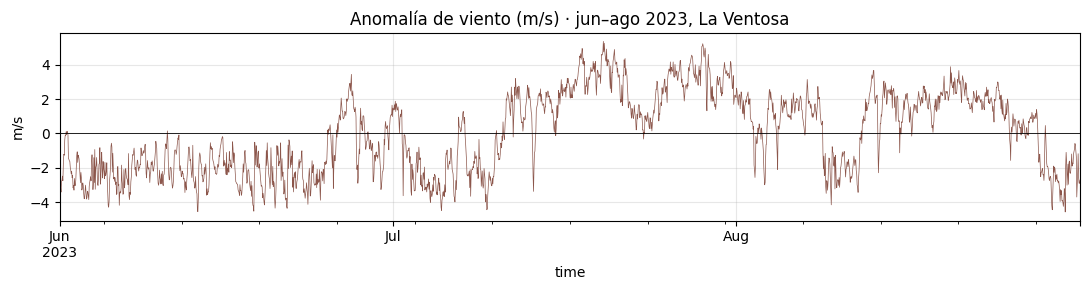

In [12]:
ws_anom = viento - viento.index.hour.map(clima_h)

fig, ax = plt.subplots(figsize=(11, 3))
ws_anom.plot(ax=ax, lw=0.5, color="C5")
ax.axhline(0, color="k", lw=0.6)
ax.set_title("Anomalía de viento (m/s) · jun–ago 2023, La Ventosa")
ax.set_ylabel("m/s")
plt.tight_layout(); plt.show()

La anomalía oscila alrededor de cero, sin patrón obvio a ojo. **Ahí vive la dinámica
estocástica que ARMA puede modelar.** Cumplimos los supuestos:

- Estacionariedad ✓
- Sin estacionalidad determinista pendiente ✓

> **Lección.** ARMA modela la dinámica estocástica que queda **después** de quitar
> lo determinista (tendencia, estacionalidad). No es magia: si le metes ciclo diario,
> te lo devolverá íntegro en los residuales.

## P3 · Identificación · 5 min

ADF · anomalía viento:  estadístico = -2.662,  p = 0.0809  →  NO estacionaria


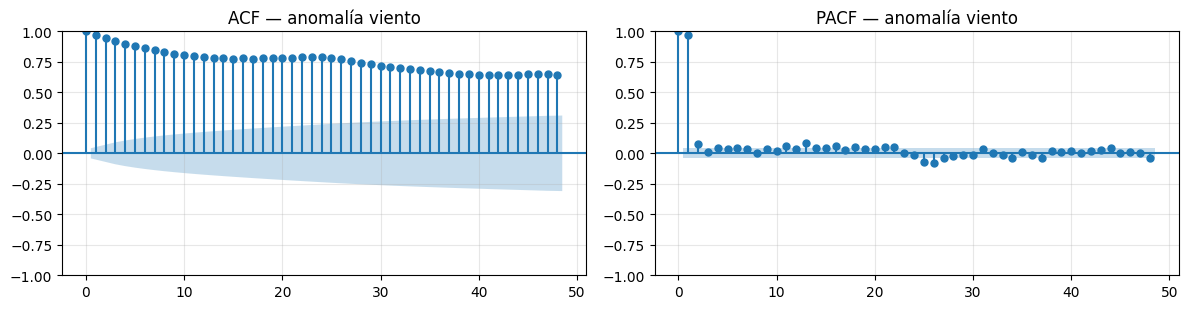

In [13]:
mirar(ws_anom, "anomalía viento", lags=48)

**Lectura.**

- **ADF:** rechaza raíz unitaria (p ≈ 0). Estacionaria.
- **ACF:** decae **lentamente** — hay memoria que va más allá de un par de lags.
- **PACF:** picos claros en lags 1, 2 y posiblemente 3; después casi todo dentro de banda.

**Hipótesis de orden:** AR(2) o AR(3). Pero empezamos humildes con **AR(1)** y subimos
si los diagnósticos lo piden. Box-Jenkins no premia adivinar, premia **iterar con criterio**.

> **Pausa pedagógica (90 s).** Antes de correr la siguiente celda, pedir a los alumnos
> que **propongan un orden $(p, q)$** mirando ACF y PACF. Recoger 3-4 propuestas en el
> pizarrón. Casi seguro habrá un mix de AR(2), AR(3), ARMA(1,1) y ARMA(2,1). Esa
> diversidad es exactamente la realidad: identificación visual da *un punto de partida*,
> no una respuesta única.

## P4 · Iteración Box-Jenkins · 15 min

Tres ajustes con la misma rutina: **estimar → diagnosticar → decidir**.

### Iteración 1 · AR(1)

phi = 0.970    AIC = 3814.2


/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


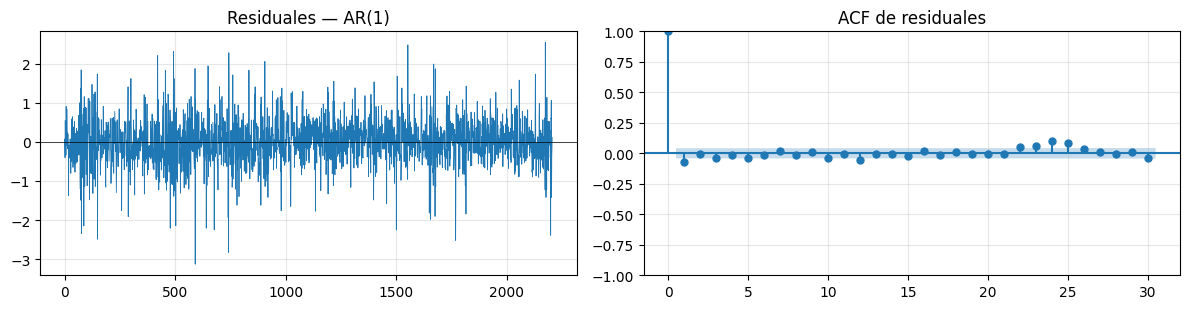

Ljung-Box · AR(1)
    lb_stat  lb_pvalue
10  22.7234     0.0118
20  32.3597     0.0396


,lb_stat,lb_pvalue
10,22.723397,0.011815
20,32.359656,0.039614


In [14]:
ar1_w = ARIMA(ws_anom, order=(1, 0, 0)).fit()
print(f"phi = {ar1_w.params['ar.L1']:.3f}    AIC = {ar1_w.aic:.1f}")
diagnostico(ar1_w, "AR(1)", lags=30)

**Veredicto AR(1).** Ljung-Box rechaza con $p$ muy pequeño → los residuales **no** son
ruido blanco. La ACF residual muestra picos en los primeros lags. AR(1) capturó la
persistencia más obvia pero dejó estructura sin modelar.

**Decisión:** subir orden.

> **Para discutir con la clase.**
> - $\phi$ está cerca de 0.85. **¿Qué dice eso físicamente?** (Vida media =
>   $-\ln 2 / \ln \phi \approx 4.3$ horas. Una desviación de la climatología tarda ~4 h
>   en reducirse a la mitad. Esa es la *escala de memoria sinóptica* del viento en La Ventosa).
> - Si paráramos aquí y usáramos este AR(1) en producción, ¿qué se rompería?
>   (Subestimaríamos la incertidumbre — los IC del pronóstico serían demasiado estrechos
>   porque asumen residuales blancos; con residuales correlacionados, los errores reales
>   son más grandes que los teóricos).

### Iteración 2 · AR(2)

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0943      0.441     -0.214      0.831      -0.958       0.769
ar.L1          0.8969      0.016     56.605      0.000       0.866       0.928
ar.L2          0.0752      0.015      4.986      0.000       0.046       0.105
sigma2         0.3262      0.007     47.793      0.000       0.313       0.340

AIC = 3803.7  (AR(1) tenía 3814.2)


/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


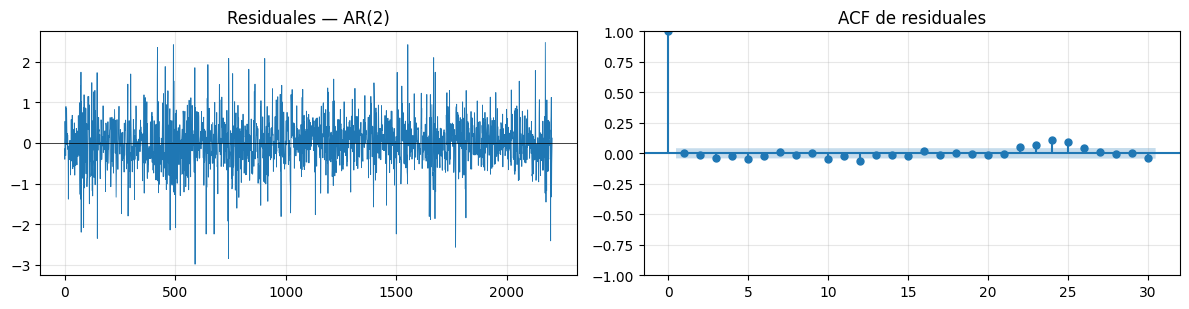

Ljung-Box · AR(2)
    lb_stat  lb_pvalue
10  15.4368     0.1169
20  27.7842     0.1146


,lb_stat,lb_pvalue
10,15.436801,0.116930
20,27.784229,0.114606


In [15]:
ar2_w = ARIMA(ws_anom, order=(2, 0, 0)).fit()
print(ar2_w.summary().tables[1])
print(f"\nAIC = {ar2_w.aic:.1f}  (AR(1) tenía {ar1_w.aic:.1f})")
diagnostico(ar2_w, "AR(2)", lags=30)

**Veredicto AR(2).** El AIC bajó claramente; ambos coeficientes son significativos.
La ACF residual está más limpia, pero Ljung-Box probablemente sigue rechazando o
queda al borde. Queda algún rastro de correlación.

**Decisión:** probar **ARMA(2,1)** — añadir un término MA suele cerrar el resto de
la estructura sin escalar mucho el orden AR. Es la jugada típica en Box-Jenkins
cuando un AR(p) "casi alcanza".

> **Para discutir con la clase.**
> - ¿Por qué probamos ARMA(2,1) y no AR(3)? (Empíricamente, en muchas series un MA(1)
>   captura "el último eco" más eficientemente que un AR adicional. ARMA(2,1) tiene 3
>   parámetros como AR(3), pero es más flexible. Si ARMA(2,1) no funcionara, AR(3)
>   sería la siguiente prueba).
> - ¿Cómo sabemos que no estamos sobreajustando con ARMA(2,1)? (Tres pistas: AIC sigue
>   bajando, los tres coeficientes son significativos, y los residuales se vuelven más
>   blancos. Si alguno de esos tres fallara, sería señal de sobreajuste).

### Iteración 3 · ARMA(2, 1)

/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.3471      0.843     -0.412      0.681      -2.000       1.305
ar.L1          1.8332      0.024     76.881      0.000       1.786       1.880
ar.L2         -0.8340      0.023    -35.512      0.000      -0.880      -0.788
ma.L1         -0.9378      0.017    -55.002      0.000      -0.971      -0.904
sigma2         0.3209      0.007     47.696      0.000       0.308       0.334

AIC = 3769.2


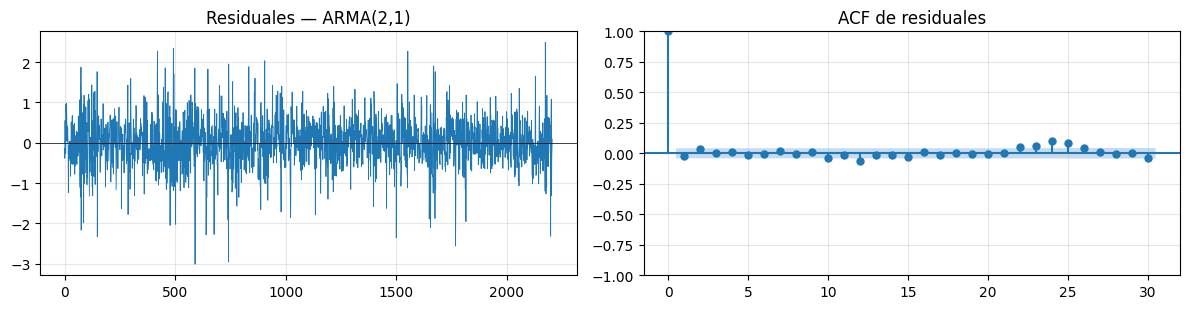

Ljung-Box · ARMA(2,1)
    lb_stat  lb_pvalue
10   9.7992     0.4583
20  22.2304     0.3281


,lb_stat,lb_pvalue
10,9.799193,0.458284
20,22.230393,0.328141


In [16]:
arma21_w = ARIMA(ws_anom, order=(2, 0, 1)).fit()
print(arma21_w.summary().tables[1])
print(f"\nAIC = {arma21_w.aic:.1f}")
diagnostico(arma21_w, "ARMA(2,1)", lags=30)

**Veredicto ARMA(2,1).** El AIC baja todavía más, los tres coeficientes son
significativos y Ljung-Box ya **no rechaza** ($p > 0.05$): los residuales son
indistinguibles de ruido blanco. **Aquí paramos** — subir más orden no aportaría.

### Resumen comparativo

In [17]:
def lb_pvalue(modelo, lag=20):
    p, d, q = modelo.model.order
    resid = modelo.resid.iloc[max(p, q):]
    return acorr_ljungbox(resid, lags=[lag], return_df=True)["lb_pvalue"].iloc[0]

resumen = pd.DataFrame({
    "AIC":             [ar1_w.aic, ar2_w.aic, arma21_w.aic],
    "BIC":             [ar1_w.bic, ar2_w.bic, arma21_w.bic],
    "LB p-value (20)": [lb_pvalue(ar1_w), lb_pvalue(ar2_w), lb_pvalue(arma21_w)],
}, index=["AR(1)", "AR(2)", "ARMA(2,1)"]).round(4)
print(resumen)

                 AIC        BIC  LB p-value (20)
AR(1)      3814.1805  3831.2800           0.0396
AR(2)      3803.6837  3826.4831           0.1146
ARMA(2,1)  3769.2380  3797.7372           0.3281


**Lectura de la tabla — momento clave de la clase.**

- El **AIC baja monotónicamente**: el modelo absorbe más estructura sin sobreajustar.
- El **p-value de Ljung-Box crece** hacia 1: residuales cada vez más "blancos".
- **Criterio de parada:** LB no rechaza Y los nuevos coeficientes son significativos.

> **Lección operativa.** Box-Jenkins es un *loop*, no una receta. Subes orden, miras
> Ljung-Box, repites. Cuando los residuales son blancos, paras. Si nunca lo logras
> subiendo orden, el problema no es de orden — es de **familia** (te falta
> estacionalidad, exógenas, o no linealidad).

> **Para discutir con la clase (síntesis).**
> - Si el AIC siguiera bajando con ARMA(3,2), ¿lo elegirían? (No necesariamente —
>   si Ljung-Box ya no rechaza con ARMA(2,1), añadir parámetros es **complejidad gratis**.
>   Principio de parsimonia: gana el modelo más simple entre los adecuados).
> - ¿Por qué Ljung-Box mira 10 y 20 lags? (10 ≈ media jornada en datos horarios; 20 ≈
>   día completo. Si el modelo deja autocorrelación residual a esos horizontes, el
>   pronóstico de corto plazo será sesgado).
> - ¿Qué harían si los datos fueran 5-minutales en vez de horarios? (Más obs por
>   ciclo diario → más estructura fina → probablemente necesitarían orden mayor.
>   Pero también: más ruido de medición que el modelo capturaría como dinámica falsa.
>   Trade-off entre resolución y señal-ruido).

## P5 · Pronóstico, frontera y puente a SARIMA · 10 min

### Pronóstico a 24 h

Pronosticamos la **anomalía** con el ARMA(2,1) y reincorporamos la climatología
horaria para reconstruir el viento físico.

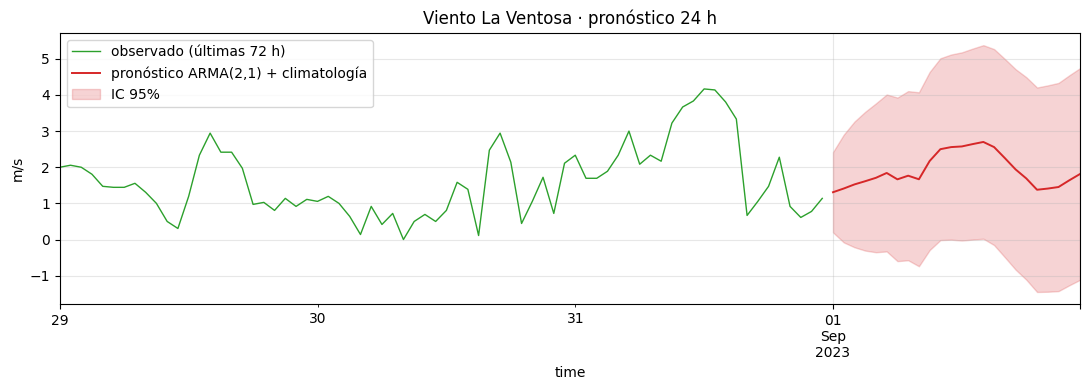

In [18]:
H = 24  # horizonte: 24 horas
fc = arma21_w.get_forecast(steps=H)

fc_anom = fc.predicted_mean
ic_anom = fc.conf_int(alpha=0.05)

horas_fc = fc_anom.index.hour
fc_real = fc_anom + horas_fc.map(clima_h)
ic_real = ic_anom.add(horas_fc.map(clima_h).values, axis=0)

ventana = viento.iloc[-72:]

fig, ax = plt.subplots(figsize=(11, 4))
ventana.plot(ax=ax, lw=1.0, color="C2", label="observado (últimas 72 h)")
fc_real.plot(ax=ax, color="C3", lw=1.4, label="pronóstico ARMA(2,1) + climatología")
ax.fill_between(fc_real.index, ic_real.iloc[:, 0], ic_real.iloc[:, 1],
                color="C3", alpha=0.2, label="IC 95%")
ax.set_title("Viento La Ventosa · pronóstico 24 h")
ax.set_ylabel("m/s"); ax.legend(); plt.tight_layout(); plt.show()

**Cómo leer el pronóstico.**

- La **anomalía** decae geométricamente hacia cero — comportamiento canónico de un
  ARMA estable.
- Reincorporada la climatología, el pronóstico replica el ciclo diario heredado de
  los datos.
- El IC 95% se ensancha hasta el ancho de la varianza incondicional. Sin información
  exógena (presión, temperatura), un modelo univariado no puede prometer más.

> **Para discutir con la clase.**
> - ¿Confiarían en este pronóstico para **operar** un parque eólico mañana? Argumentar
>   ambos lados. (A favor: residuales blancos, IC honesto, modelo simple y auditable.
>   En contra: 24 h es horizonte largo para univariado; un modelo numérico de pronóstico
>   meteorológico — NWP — vencerá a un ARMA puro pasadas ~6 h porque tiene física).
> - ¿En qué horizonte ARMA es competitivo? (Muy corto plazo, hasta ~3-6 h. Por eso
>   los operadores de mercado eléctrico usan ARMA / persistencia para *nowcasting* y
>   NWP/ensemble para horizontes mayores).
> - ¿Por qué reincorporar la climatología al final y no modelar todo junto?
>   (Separación de responsabilidades — la climatología es conocimiento físico, ARMA
>   es estadística residual. Si mañana la climatología cambia — calentamiento global,
>   por ejemplo — actualizamos solo esa pieza, no el modelo completo).

### La frontera · ¿qué pasa si NO desestacionalizamos?

Provocación: ajustemos AR(2) directamente sobre el viento crudo (con ciclo diario).

/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


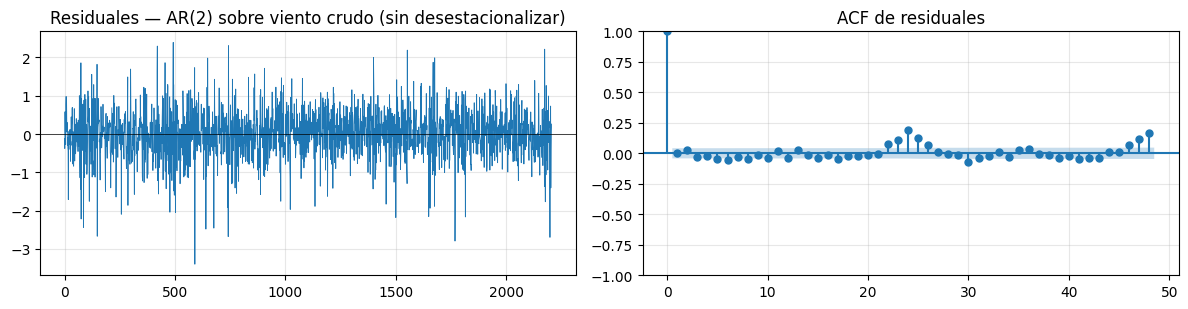

Ljung-Box · AR(2) sobre viento crudo (sin desestacionalizar)
    lb_stat  lb_pvalue
10  25.9612     0.0038
20  42.4661     0.0024


,lb_stat,lb_pvalue
10,25.961152,0.003793
20,42.466060,0.002404


In [19]:
ar2_crudo = ARIMA(viento, order=(2, 0, 0)).fit()
diagnostico(ar2_crudo, "AR(2) sobre viento crudo (sin desestacionalizar)", lags=48)

**Mira la ACF residual con cuidado.** Aparecen **picos en lags 24, 48, 72** — el
ciclo diario que ARMA no puede capturar y que se filtró íntegro a los residuales.
Subir orden no lo arregla: ARMA no tiene mecanismo *explícito* para estacionalidad.

**Esa es la frontera de aplicabilidad de ARMA.** Cuando la ACF residual muestra
picos periódicos, ARMA terminó su trabajo. Lo que sigue:

- **SARIMA** $(p, d, q)(P, D, Q)_s$ — ARIMA con componente estacional explícito de
  período $s$. Es la respuesta directa al problema que acabas de ver.
- **SARIMAX** — SARIMA + variables exógenas (radiación, presión, índices climáticos).
- **Modelos espacio-estados** — descomposición estructural y filtros de Kalman.

Esa es la próxima sesión. Esta termina aquí: con la frontera identificada y el
siguiente modelo motivado por **necesidad observada**, no por currículum.

> **Cierre con la clase (preguntas de salida).**
> - En una frase: **¿qué hace AR diferente de MA?** (AR usa pasado *observado*; MA usa
>   pasado *de innovaciones*. Una es inercia; la otra es eco de choques).
> - ¿Cuál es **la única figura** que el alumno debe poder dibujar de memoria? (El
>   ciclo Box-Jenkins: identificar → estimar → diagnosticar → loop).
> - ¿En qué **dos pruebas** confía Box-Jenkins? (ADF para estacionariedad de la serie;
>   Ljung-Box para blancura de los residuales).

# Cierre y materiales adicionales

## Lo que te llevas

1. **Identificar antes de estimar.** ADF + ACF + PACF te dicen qué orden probar
   *antes* de tocar `ARIMA(...)`.
2. **Diagnosticar antes de creerle al modelo.** Ljung-Box sobre residuales es
   no negociable. Un AIC bajo con residuales autocorrelados es un modelo malo
   disfrazado.
3. **Iterar con criterio.** Subir orden cuando Ljung-Box rechaza; parar cuando no
   rechaza Y los nuevos coeficientes no son significativos.
4. **Saber el límite.** Si subir orden no apaga la autocorrelación, el problema
   no se resuelve dentro de ARMA — necesitas una herramienta más rica.

## Ejercicios para entregar

1. Descarga viento horario de **otro mes** (ene–mar) para La Ventosa. ¿$\phi_1$ y
   $\phi_2$ cambian? Intenta justificar físicamente por qué tendría sentido que
   cambiaran (régimen sinóptico vs régimen térmico).
2. Sobre el ARMA(2,1) ya ajustado, repite el pronóstico con **horizonte de 72 h**
   y discute cómo se compara la incertidumbre del modelo con la variabilidad real
   esperada del viento.
3. Ajusta deliberadamente AR(5) y ARMA(3,2) sobre la anomalía. ¿Cuál gana en AIC?
   ¿Cuál gana en parsimonia? ¿Cuál elegirías para producción y por qué?

## Lecturas

- Box, Jenkins, Reinsel, Ljung (2015). *Time Series Analysis: Forecasting and Control*
  (5th ed.). Caps. 3–4.
- Cryer & Chan (2008). *Time Series Analysis: With Applications in R*. Caps. 4–6.
- Hyndman & Athanasopoulos. *Forecasting: Principles and Practice*.
  https://otexts.com/fpp3/ (cap. 9).

## Apéndice · descarga del CSV

```bash
curl "https://archive-api.open-meteo.com/v1/archive?\
latitude=16.55&longitude=-94.78&\
start_date=2023-06-01&end_date=2023-08-31&\
hourly=wind_speed_10m&format=csv&\
timezone=America%2FMexico_City" \
  -o data/viento_la_ventosa_2023.csv
```

Open-Meteo entrega reanálisis ERA5 sin autenticación. Calidad comparable a
NREL WIND Toolkit para evaluación de recurso.

Cita:
> Hersbach, H., et al. (2020). *The ERA5 global reanalysis*. QJRMS, 146, 1999–2049.